In [1]:
import numpy as np
from numpy.random import default_rng
from scipy.integrate import quad, dblquad
from scipy.optimize import minimize_scalar, minimize
from functools import lru_cache
import matplotlib.pyplot as plt
from scipy.special import erf
import emcee

# Test RV case

This sets up a sample RV curve to test the statistics on.

Text(0, 0.5, 'RV (km/s)')

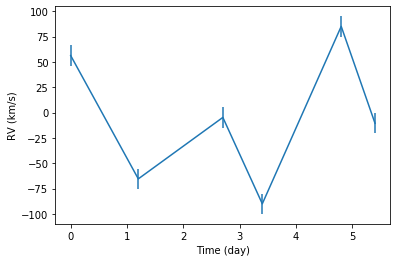

In [141]:
true_K = 90
true_P = 2.5
true_phi = 0.3 * np.pi
true_vi = 0
true_sini = 1

times = np.array([0.0, 1.2, 2.7, 3.4, 4.8, 5.4])
model_rvs = true_K * true_sini * np.cos(2 * np.pi / true_P * times + true_phi) + true_vi

sig_rv = 10
obs_rvs = model_rvs + sig_rv * np.random.randn(len(model_rvs))

f, ax = plt.subplots(1)
ax.errorbar(times, obs_rvs, yerr=sig_rv)
ax.set_xlabel("Time (day)")
ax.set_ylabel("RV (km/s)")

In [128]:
def norm(val, mean, sig):
    '''A function representing a normal distribution.'''
    return np.exp(-(val - mean)**2 / 2 / sig**2) / np.sqrt(2 * np.pi) / sig
def ln_norm(val, mean, sig):
    return - (val - mean)**2 / 2 / sig**2 - np.log(2 * np.pi * sig**2) / 2
def rv_model(ti, K, P, phi, vo):
    '''Calculate the model RV.'''
    return K * np.cos(2 * np.pi / P * ti + phi) + vo
def ln_integrand_vi_given_ti_K_P_phi_vgal(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, x, phi):
    '''Return the integrand for calculating the likelihood.'''
    # I want to make sig_viarr either a vector or a scalar. This can be done through:
    sig_viarr = np.ones(len(viarr)) * sig_viarr
    x = np.ones(1) * x
    phi = np.ones(1) * phi
    # If sig_viarr is a scalar, it should now be a vector. If it was a vector, it should still be the same.
    tot = np.sum(
        -(viarr - (K * np.cos(2*np.pi/P * tiarr + phi[:,np.newaxis,np.newaxis]) + vgal + 
                   np.sqrt(2) * sig_vgal * x[:,np.newaxis]))**2/ 2 / sig_viarr**2 - 
        np.log(2 * np.pi * sig_viarr**2) / 2, axis=-1) - x**2  - np.log(np.pi) / 2 - np.log(2*np.pi)
#    if not np.isfinite(np.exp(np.squeeze(tot) - -7185.6255811080055)):
#        print("X: {0:.3f}, Phi: {1:.3f}".format(x, phi))
#    print(np.exp(np.squeeze(tot) - -7185.6255811080055))
    return np.squeeze(tot)

def ln_integrand_vi_given_ti_K_P_phi_vgal_sini(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, x, phi, sini):
    '''Return the integrand for calculating the likelihood.'''
    # I want to make sig_viarr either a vector or a scalar. This can be done through:
    sig_viarr = np.ones(len(viarr)) * sig_viarr
    x = np.ones(1) * x
    phi = np.ones(1) * phi
    sini = np.ones(1) * sini
    # If sig_viarr is a scalar, it should now be a vector. If it was a vector, it should still be the same.
    tot = np.sum(
        -(viarr - (K * sini[:,np.newaxis,np.newaxis] * np.cos(
            2*np.pi/P * tiarr + phi[:,np.newaxis,np.newaxis,np.newaxis]) + vgal + 
                   np.sqrt(2) * sig_vgal * x[:,np.newaxis]))**2/ 2 / sig_viarr**2 - 
        np.log(2 * np.pi * sig_viarr**2) / 2, axis=-1) - x**2 + np.log(sini[:,np.newaxis]) - np.log(np.pi) / 2 - np.log(2*np.pi)
#    if not np.isfinite(np.exp(np.squeeze(tot) - -7185.6255811080055)):
#        print("X: {0:.3f}, Phi: {1:.3f}".format(x, phi))
#    print(np.exp(np.squeeze(tot) - -7185.6255811080055))
    return np.squeeze(tot)

def ln_integrand_vi_given_ti_K_P_phi_vgal_gradient(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, x, phi):
    '''Return the gradient over x and phi of the log of the integrand.'''
    dfdx = np.sum((
        viarr - (K * np.cos(2*np.pi/P * tiarr + phi) + vgal + np.sqrt(2) * sig_vgal * x)) * 
        np.sqrt(2) * sig_vgal / sig_viarr**2, axis=-1) - 2 * x
    dfdphi = np.sum(-(
        viarr - (K * np.cos(2*np.pi/P * tiarr + phi) + vgal + np.sqrt(2) * sig_vgal * x)) * 
        K * np.sin(2*np.pi/P * tiarr + phi) / sig_viarr**2, axis=-1)
    return np.array([dfdx, dfdphi]).reshape(2)

def ln_integrand_vi_given_ti_K_P_phi_vgal_sini_gradient(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, x, phi, sini):
    '''Return the gradient over x and phi of the log of the integrand.'''
    dfdx = np.sum((
        viarr - (K * sini * np.cos(2*np.pi/P * tiarr + phi) + vgal + np.sqrt(2) * sig_vgal * x)) * 
        np.sqrt(2) * sig_vgal / sig_viarr**2, axis=-1) - 2 * x
    dfdphi = np.sum(-(
        viarr - (K * sini * np.cos(2*np.pi/P * tiarr + phi) + vgal + np.sqrt(2) * sig_vgal * x)) * 
        K * np.sin(2*np.pi/P * tiarr + phi) / sig_viarr**2, axis=-1)
    dfdsini = np.sum((
        viarr - (K * sini * np.cos(2*np.pi/P * tiarr + phi) + vgal + np.sqrt(2) * sig_vgal * x)) * 
        K * np.cos(2*np.pi/P * tiarr + phi) / sig_viarr**2, axis=-1) + 1 / sini
    return np.array([dfdx, dfdphi, dfdsini]).reshape(3)

def likelihood_vi_given_ti_K_P_vgal(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal):
    '''Likelihood marginalized over phi.'''
    res1 = minimize(
        lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal(
            viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, args[0], args[1]), [0, np.pi/2], method="CG", 
        jac=lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal_gradient(
            viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, args[0], args[1]))
    print(res1)
    res2 = minimize(
        lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal(
            viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, args[0], args[1]), [0, 2*np.pi-res1.x[1]], method="CG", 
        jac=lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal_gradient(
            viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, args[0], args[1]))
    print(res2)
    # In some cases, taking the exponent of the integrand leaves something so small that the integrate function
    # considers it 0. So what I'm going to do is use the expected peak, and normalize it so that integrate works
    # over much larger values.
    ln_norm = min(
        ln_integrand_vi_given_ti_K_P_phi_vgal(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, res1.x[0], res1.x[1]),
        ln_integrand_vi_given_ti_K_P_phi_vgal(viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, res2.x[0], res2.x[1]))
    print("Normalization Factor: {0:.4g}".format(ln_norm))
    # I'm going to first integrate over phi, and then x.
    def phi_integrand(phiphi):
        tot = quad(
            lambda xx: np.exp(ln_integrand_vi_given_ti_K_P_phi_vgal(
                viarr, tiarr, sig_viarr, K, P, vgal, sig_vgal, xx, phiphi) - ln_norm), -10, 10, points=[-1, 1])
        if not np.isfinite(tot[0]):
            print("Phi: {0:.3f}; Prob: {1:.3f}".format(phiphi, tot[0]))
        return tot[0]
    prob, err = quad(phi_integrand, 0, 2*np.pi, points=[res1.x[1], np.pi, res2.x[1]])
    print("Total Probability: {0:.4g}".format(prob))
    return prob * np.exp(ln_norm), err

In [17]:
testnorm = -7185.6255811080055
testtot = quad(
            lambda xx: np.exp(ln_integrand_vi_given_ti_K_P_phi_vgal(
                obs_rvs, times, sig_rv, 0, true_P, 0, 20, xx, 0) - testnorm), -10, 10, points=[-1, 1])
print(testtot[0])

1.0004374207349167e+267


In [91]:
likelihood_vi_given_ti_K_P_vgal(obs_rvs, times, sig_rv, true_K, true_P, 0, 20)[0]

     fun: 8.462645863412568
     jac: array([ 8.77596606e-15, -0.00000000e+00])
 message: 'Optimization terminated successfully.'
    nfev: 3
     nit: 1
    njev: 3
  status: 0
 success: True
       x: array([-0.00362004,  1.57079633])
     fun: 8.462645863412568
     jac: array([ 8.77596606e-15, -0.00000000e+00])
 message: 'Optimization terminated successfully.'
    nfev: 3
     nit: 1
    njev: 3
  status: 0
 success: True
       x: array([-3.62004232e-03,  4.71238898e+00])
Normalization Factor: -8.463
Total Probability: 0.2273


4.8004099128646945e-05

In [115]:
likelihood_vi_given_ti_K_P_vgal(obs_rvs, times, sig_rv, 90, true_P, 0, 20)[0] / likelihood_vi_given_ti_K_P_vgal(obs_rvs, times, sig_rv, 0, true_P, 0, 20)[0]

     fun: 24.374057479579005
     jac: array([ 1.18953120e-08, -9.28888966e-10])
 message: 'Optimization terminated successfully.'
    nfev: 15
     nit: 7
    njev: 15
  status: 0
 success: True
       x: array([0.16240845, 1.04447466])
     fun: 24.374057479579
     jac: array([-2.08744662e-08, -1.13631504e-09])
 message: 'Optimization terminated successfully.'
    nfev: 24
     nit: 10
    njev: 24
  status: 0
 success: True
       x: array([0.16240845, 7.32765997])
Normalization Factor: -24.37
Total Probability: 0.05946
     fun: 137.74006667094255
     jac: array([ 9.76996262e-15, -0.00000000e+00])
 message: 'Optimization terminated successfully.'
    nfev: 3
     nit: 1
    njev: 3
  status: 0
 success: True
       x: array([-0.17936223,  1.57079633])
     fun: 137.74006667094255
     jac: array([ 9.76996262e-15, -0.00000000e+00])
 message: 'Optimization terminated successfully.'
    nfev: 3
     nit: 1
    njev: 3
  status: 0
 success: True
       x: array([-0.17936223,  4.71238

4.578241325488282e+47

In [10]:
Kvals = np.linspace(0, 50, 20)
Knorm = likelihood_vi_given_ti_K_P_vgal(obs_rvs, times, sig_rv, 0, true_P, 0, 20)[0]
Kprobs = np.zeros_like(Kvals)
for i, testK in enumerate(Kvals):
    Kprobs[i] = likelihood_vi_given_ti_K_P_vgal(obs_rvs, times, sig_rv, testK, true_P, 0, 20)[0] / Knorm
    
plt.plot(Kvals, Kprobs, 'k-')

ZeroDivisionError: float division by zero

In [140]:
# Test whether the gradient and likelihood functions are working correctly.
t_test = 0
v_test = 0
sig_rv_test = 1
K_test = 1
P_test = 1
x_test = 0
vgal_test = 0
sig_vgal_test = 1
phi_test = 0
sini_test = 1

pred_val = (
    -(v_test - (
        K_test * sini_test * np.cos(
            t_test * 2 * np.pi / P_test + phi_test) + vgal_test + np.sqrt(2) * sig_vgal_test * x_test))**2 / 
    2 / sig_rv_test**2 - x_test**2 + np.log(sini_test) - np.log(2*np.pi*sig_rv_test**2) / 2 - np.log(np.pi) / 2 - np.log(2*np.pi))
print("Predicted: {0:.5g}".format(pred_val))
print("Tested: {0:.5g}".format(ln_integrand_vi_given_ti_K_P_phi_vgal_sini(
    np.array([v_test]), np.array([t_test]), sig_rv_test, K_test, P_test, vgal_test, sig_vgal_test, x_test, phi_test, sini_test)))

pred_grad_x = (
    (v_test - (K_test * sini_test * np.cos(2*np.pi/P_test*t_test + phi_test) + vgal_test + np.sqrt(2) * sig_vgal_test * x_test)) *
     np.sqrt(2) * sig_vgal_test / sig_rv_test**2 - 2 * x_test)
pred_grad_phi = (
    -(v_test - (K_test * sini_test * np.cos(2*np.pi/P_test*t_test + phi_test) + vgal_test + np.sqrt(2) * sig_vgal_test * x_test)) *
     K_test * sini_test * np.sin(2*np.pi/P_test*t_test + phi_test) / sig_rv_test**2)
pred_grad_sini = (
    (v_test - (K_test * sini_test * np.cos(2*np.pi/P_test*t_test + phi_test) + vgal_test + np.sqrt(2) * sig_vgal_test * x_test)) *
     K_test * np.cos(2*np.pi/P_test*t_test + phi_test) / sig_rv_test**2 + 1 / sini_test)
print("Predicted Gradient {0}".format([pred_grad_x, pred_grad_phi, pred_grad_sini]))
print("Tested Gradient: {0}".format(ln_integrand_vi_given_ti_K_P_phi_vgal_sini_gradient(np.array([v_test]), np.array([t_test]), sig_rv_test, K_test, P_test, vgal_test, sig_vgal_test, x_test, phi_test, sini_test)))

Predicted: -3.8292
Tested: -3.8292
Predicted Gradient [-1.4142135623730951, -4.898587196589413e-15, 0.0]
Tested Gradient: [-1.41421356e+00 -4.89858720e-15  0.00000000e+00]


(100, 400)


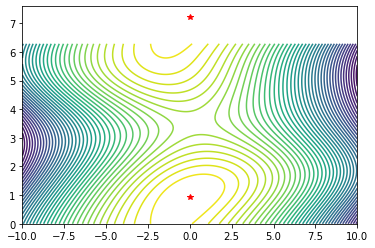

In [83]:
phivals = np.linspace(0, 2*np.pi, 100)
xvals = np.linspace(-10, 10, 400)
lnint_values = ln_integrand_vi_given_ti_K_P_phi_vgal(obs_rvs, times, sig_rv, true_K, true_P, 0, 20, xvals, phivals)
print(lnint_values.shape)
plt.contour(xvals, phivals, lnint_values, 50)
res1 = minimize(
    lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal(
            obs_rvs, times, sig_rv, true_K, true_P, 0, 20, args[0], args[1]), [0, np.pi/2], method="CG", 
    jac=lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal_gradient(
            obs_rvs, times, sig_rv, true_K, true_P, 0, 20, args[0], args[1]))
res2 = minimize(
    lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal(
            obs_rvs, times, sig_rv, true_K, true_P, 0, 20, args[0], args[1]), [0, 2*np.pi-res1.x[1]], method="CG", 
    jac=lambda args: -ln_integrand_vi_given_ti_K_P_phi_vgal_gradient(
            obs_rvs, times, sig_rv, true_K, true_P, 0, 20, args[0], args[1]))
plt.plot([res1.x[0]], [res1.x[1]], 'r*')
plt.plot([res2.x[0]], [res2.x[1]], 'r*')


In [122]:
ln_integrand_vi_given_ti_K_P_phi_vgal_sini(obs_rvs, times, sig_rv, true_K, true_P, 0, 20, 0, 0, 1)

array(-112.73364452)

In [187]:
class MCIntegrate:
    def __init__(self, xlow, xhigh, func, inregion, xmap=None, seed=None):
        '''Create the MonteCarlo Integration.'''
        self.xlo = xlow # Lower region of integration
        self.xhi = xhigh # Higher region of integration
        self.ndim = np.shape(self.xlo) # number of input dimensions
        if xmap:
            self.nfun = func(xmap(self.xlo)).shape # Number of output dimensions
        else:
            self.nfun = func(self.xlo).shape
        self.n = 0 # number of points samples
        
        self.ff = np.zeros(self.nfun) # Answer
        self.fferr = np.zeros(self.nfun) # Error in answer

        self.sf = np.zeros(self.nfun) # Sum of f
        self.sferr = np.zeros(self.nfun) # Sum of f-squared
        
        self.vol = np.product(self.xhi - self.xlo)
        
        self.func = func # The function
        self.xmap = xmap # A way to perform change of variables
        self.inregion = inregion # A function that tells you whether a supplied point is in the desired region.
        self.ran = default_rng(seed) # Set the seed for the random number generator.
        
    def step(self, nstep):
        '''Add nstep number of evaluations to the MonteCarlo Integration'''
        for i in range(nstep):
            randx = self.xlo + (self.xhi-self.xlo) * self.ran.random(self.ndim)
            if self.xmap:
                xx = self.xmap(randx)
            else:
                xx = randx
            
            if self.inregion(xx):
                fn = self.func(xx)
                self.sf = self.sf + fn
                self.sferr = self.sferr + fn**2
        self.n = self.n + nstep
                    
        
    def calcanswers(self):
        '''Calculate answers for the integrals using the current sums.'''
        self.ff = self.vol * self.sf / self.n
        self.fferr = self.vol * np.sqrt((self.sferr / self.n - (self.sf/self.n)**2) / self.n)

In [180]:
def torusfuncs(coord):
    '''A function to evaluate the four integrals in each element at the given 3-element coordinate..
    
    First element is just the weight with density=1
    Second element is x times the density
    Third element is y times the density
    Fourth element is z times the density.'''
    den = 1
    intarr = np.zeros(4)
    intarr[0] = den
    intarr[1:] = coord * den
    return intarr

def torusregion(coord):
    '''Return whether you are in the region defined by the torus.'''
    return coord[2]**2 + (np.sqrt(coord[0]**2 + coord[1]**2) - 3) <= 1


In [192]:
xlo = np.array([1, -3, -1])
xhi = np.array([4, 4, 1])
mymc = MCIntegrate(xlo, xhi, torusfuncs, torusregion, None, 10201)
mymc.step(1000000)
mymc.calcanswers()

In [197]:
def simplefunc(coord):
    return coord**2

def simpleregion(coord):
    return True

In [200]:
xlo = np.array([0])
xhi = np.array([1])
mymc = MCIntegrate(xlo, xhi, simplefunc, simpleregion, None, 10201)
mymc.step(1000000)
mymc.calcanswers()

In [201]:
print(mymc.ff)
print(mymc.fferr)

[0.33294338]
[0.00029785]


In [202]:
## Root solving now

In [256]:
# Test Minimization
sigx = 1
sigy = 3
def func(args):
    xx = args[0]
    phi = args[1]
    return np.sum(
        (obs_rvs - (true_K * np.cos(2*np.pi/true_P * times + phi) + 0 + np.sqrt(2) * 20 * xx))**2/ 2 / sig_rv**2, 
        axis=-1) + xx**2

def gradfunc(args):
    xx = args[0]
    phi = args[1]
    dfdx = np.sum(
        (obs_rvs - (true_K * np.cos(2*np.pi/true_P * times + phi) + 0 + np.sqrt(2) * 20 * xx)) / sig_rv**2 * 
        -np.sqrt(2) * 20, axis=-1)  + 2*xx
    dfdphi = np.sum(
        (obs_rvs - (true_K * np.cos(2*np.pi/true_P * times + phi) + 0 + np.sqrt(2) * 20 * xx)) / sig_rv**2 * 
        true_K * np.sin(2*np.pi/true_P * times + phi), axis=-1)
    grad = np.array([dfdx, dfdphi])
    return grad

In [252]:
minimize(f, [0, 0], method="CG", jac=gradf)

     fun: 0.1331652205735971
     jac: array([-5.94905607e-07,  5.21465473e-07])
 message: 'Optimization terminated successfully.'
    nfev: 24
     nit: 12
    njev: 24
  status: 0
 success: True
       x: array([0.00617313, 0.93755355])

In [251]:
minimize(f, [0, 2*np.pi-0.5], method="CG", jac=gradf)

     fun: 1287.4090983038104
     jac: array([1.23224031e-08, 6.91375135e-08])
 message: 'Optimization terminated successfully.'
    nfev: 19
     nit: 10
    njev: 19
  status: 0
 success: True
       x: array([-1.02000931,  5.31719479])